# Daugaard Case Study with geology-resistivity-category prior models.

This notebook contains an example of inversion of the DAUGAARD tTEM data using three different geology-resistivity prior models

In [1]:
try:
    # Check if the code is running in an IPython kernel (which includes Jupyter notebooks)
    get_ipython()
    # If the above line doesn't raise an error, it means we are in a Jupyter environment
    # Execute the magic commands using IPython's run_line_magic function
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except:
    # If get_ipython() raises an error, we are not in a Jupyter environment
    # # # # # # # # # #%load_ext autoreload
    # # # # # # # # # #%autoreload 2
    pass

import integrate as ig
import numpy as np
import os
import matplotlib.pyplot as plt
import h5py
hardcopy=True

import integrate as ig
# check if parallel computations can be performed
parallel = ig.use_parallel(showInfo=1)

Notebook detected. Parallel processing is OK.


## Download the data DAUGAARD data including non-trivial prior data

Getting data for case: DAUGAARD


Downloaded prior_detailed_invalleys_N2000000_dmax90.h5


Downloaded prior_detailed_outvalleys_N2000000_dmax90.h5


Downloaded POST_DAUGAARD_AVG_prior_detailed_invalleys_N2000000_dmax90_TX07_20231016_2x4_RC20-33_Nh280_Nf12_Nu2000000_aT1.h5


Downloaded POST_DAUGAARD_AVG_prior_detailed_outvalleys_N2000000_dmax90_TX07_20231016_2x4_RC20-33_Nh280_Nf12_Nu2000000_aT1.h5


Downloaded prior_detailed_inout_N4000000_dmax90_TX07_20231016_2x4_RC20-33_Nh280_Nf12.h5
--> Got data for case: DAUGAARD
<KeysViewHDF5 ['d_obs', 'd_std', 'i_hm', 'i_lm']>
Using hdf5 data file DAUGAARD_AVG_test.h5 with gex file TX07_20231016_2x4_RC20-33.gex


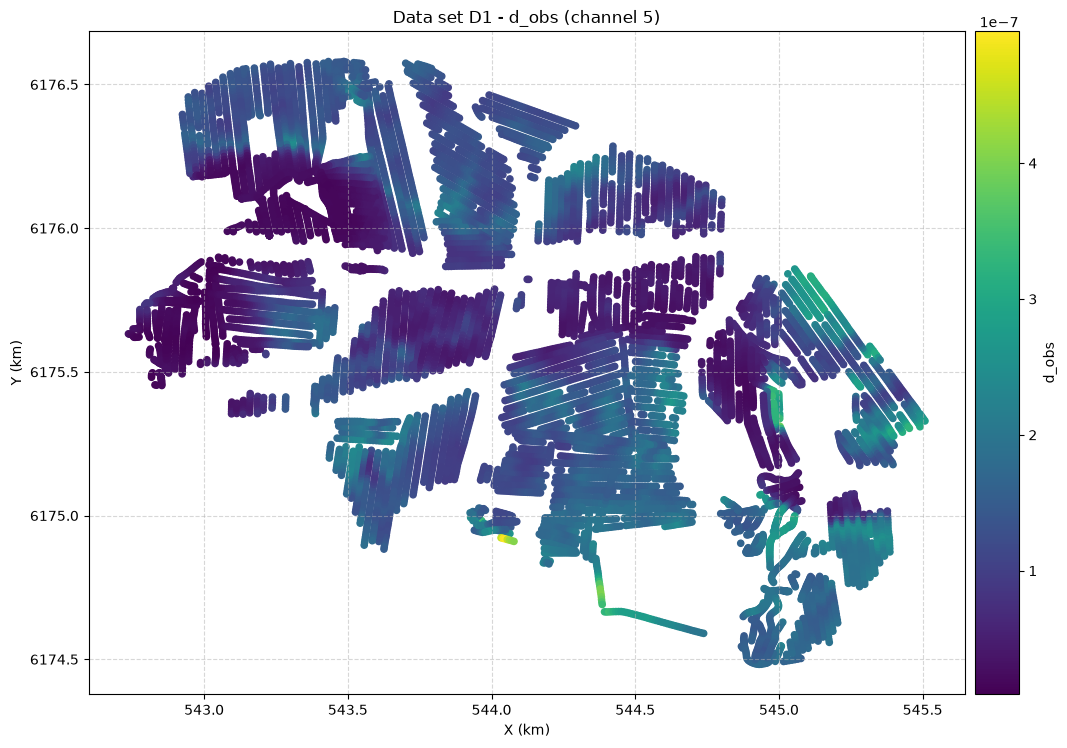

In [2]:
# For this case, we use a ready to use prior model and data set form DAUGAARD
files = ig.get_case_data(case='DAUGAARD', loadType='inout') # Load data and prior+data realizations
#files = ig.get_case_data(case='DAUGAARD', loadType='post') # # Load data and posterior realizations
#files = ig.get_case_data(case='DAUGAARD', loadAll=True) # All of the above
f_data_h5 = files[0]
file_gex= ig.get_gex_file_from_data(f_data_h5)
# check that file_gex exists
if not os.path.isfile(file_gex):
    print("file_gex=%s does not exist in the current folder." % file_gex)


# make a copy using 'os' of  DAUGAARD_AVG.h5  DAUGAARD_AVG_test.h5 using the system
f_data_h5 = 'DAUGAARD_AVG_test.h5'
os.system('cp DAUGAARD_AVG.h5 %s' % (f_data_h5))

# Update and increase noise assumption
# Read 'D1/d_std' from f_data_h5, increase it by 100% and write it back to f_data_h5
with h5py.File(f_data_h5, 'a') as f:
    print(f['D1'].keys())
    d_std = f['D1/d_std'][:]
    d_std = d_std*10
    f['D1/d_std'][:] = d_std

print('Using hdf5 data file %s with gex file %s' % (f_data_h5,file_gex))

fig=ig.plot_data_xy(f_data_h5, data_channel=5)

In [3]:
# Lets first make a small copy of the large data set available
f_prior_org_h5 = 'prior_detailed_inout_N4000000_dmax90_TX07_20231016_2x4_RC20-33_Nh280_Nf12.h5'
N_small = 100000
f_prior_h5 = ig.copy_hdf5_file(f_prior_org_h5, 'prior_test.h5',N=N_small,showInfo=3)

print("Keys in DATA")
with h5py.File(f_data_h5, 'r') as f:
    print(f.keys()) 
    
print("Keys in PRIOR")
with h5py.File(f_prior_h5, 'r') as f:
    N = f['M1'].shape[0]
    print("N=%d" % N)
    print(f.keys()) 

Trying to copy prior_detailed_inout_N4000000_dmax90_TX07_20231016_2x4_RC20-33_Nh280_Nf12.h5 to prior_test.h5
Copying D1. D1 

Copying D2. D2 Copying M1. M1 

Copying M2. M2 

Copying M3. M3 
Keys in DATA
<KeysViewHDF5 ['D1', 'ELEVATION', 'LINE', 'UTMX', 'UTMY']>
Keys in PRIOR
N=100000
<KeysViewHDF5 ['D1', 'D2', 'M1', 'M2', 'M3']>


Note how 2 types of prior data are available, but only one observed data!!

## Setting up the data and prior models
At this point we have a prior with 
three data types of  MODEL parameters
M1: Resistivity
M2: Lithology
M3: Scenario category [0,1]
## We have two types of corresponding data 
D1: tTEM data
D2: Scenario category [0,1]

D2 is simply an exact copy of, as D3=I*M3, where I is the identity operator.

This means, if som information is available about the Scenario type 
this can be provided as a new 'observation'

Here is an example of how this can be done

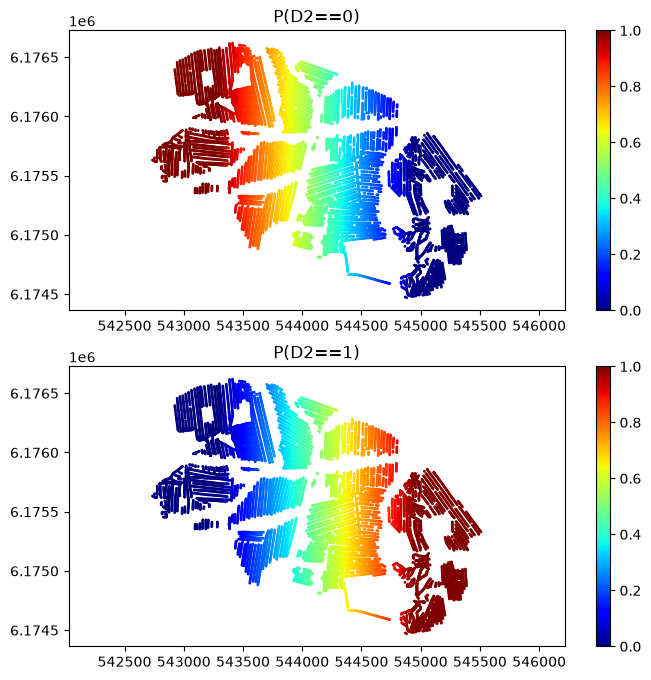

(2, 'DAUGAARD_AVG_test.h5')

In [4]:
X, Y, LINE, ELEVATION = ig.get_geometry(f_data_h5)
Xmin = np.min(X)
Xmax = np.max(X)
Xl = Xmin + 0.2*(Xmax-Xmin)
Xr = Xmin + 0.8*(Xmax-Xmin)

P0 = 1# .9999 # Probability of category 0
Pcat0 = np.zeros(len(X))-1
for i in range(len(X)):
    if X[i] < Xl:
        Pcat0[i] = P0
    elif X[i] > Xr:
        Pcat0[i] = 1-P0
    else:
        #Pcat0[i] = .5
        Pcat0[i] = P0+(1-2*P0)*(X[i]-Xl)/(Xr-Xl)

nclasses = 2
D_obs = np.zeros((len(X),2))
D_obs[:,0] = Pcat0
D_obs[:,1] = 1-Pcat0

plt.figure(figsize=(8,8))
for ic in range(nclasses):
    plt.subplot(2,1,ic+1)
    sc = plt.scatter(X, Y, c=D_obs[:,ic], cmap='jet', vmin=0, vmax=1, s=1)
    plt.colorbar(sc)
    plt.title('P(D2==%d)'%(ic))
    plt.axis('equal')
plt.show()

# ig.save_data_gaussian(f_data_h5, D_obs, 'D2', 'Scenario    )
# Now write the 'observed data as a new data type
# If the 'id' is not set, it will be set to the next available id
#ig.save_data_multinomial(D_obs, f_data_h5 = f_data_h5, showInfo=2)
# If the if is set, the data will be written to the given id, even if it allready exists
ig.save_data_multinomial(D_obs, id=2, f_data_h5 = f_data_h5, showInfo=-1)



## Ready for inversion !!

In [5]:
print("Keys in DATA")
with h5py.File(f_data_h5, 'r') as f:
    print(f.keys()) 

Keys in DATA
<KeysViewHDF5 ['D1', 'D2', 'ELEVATION', 'LINE', 'UTMX', 'UTMY']>


In [6]:
# identity copy of the prior model type for "Scenario", M3

Lets first add information directly about the scenario. 

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

...

M2-discrete:  70%|███████████████████████████████████████████████████████████████████████████▎                                | 8152/11693 [00:05<00:02, 1697.01it/s]

M2-discrete:  85%|███████████████████████████████████████████████████████████████████████████████████████████▌                | 9918/11693 [00:06<00:01, 1720.33it/s]

M3-discrete:   0%|                                                                                                                         | 0/11693 [00:00<?, ?it/s]

M3-discrete:  84%|██████████████████████████████████████████████████████████████████████████████████████████▌                 | 9799/11693 [00:01<00:00, 9798.51it/s]

Keys in POSTERIOR
<KeysViewHDF5 ['Entropy', 'Mode', 'P']>


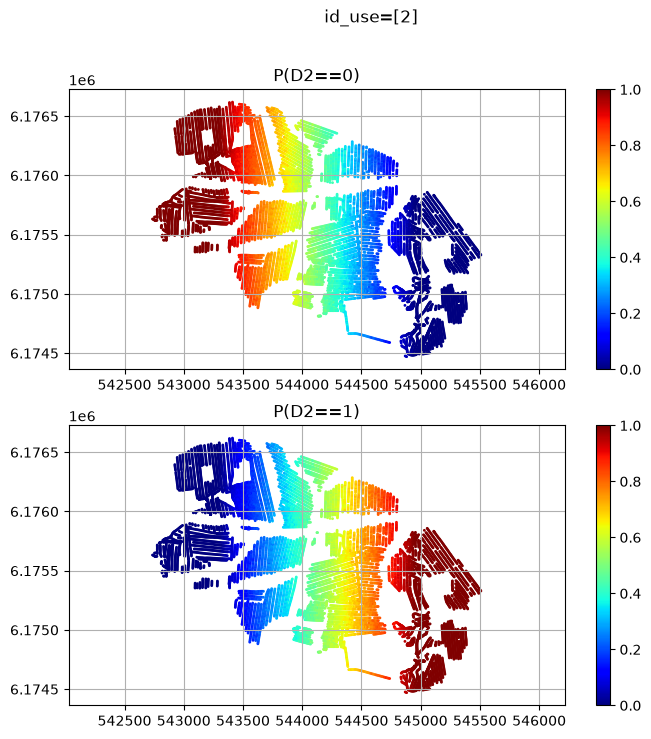

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

...

M2-discrete:  79%|█████████████████████████████████████████████████████████████████████████████████████▎                      | 9236/11693 [00:05<00:01, 1842.51it/s]

M2-discrete:  95%|█████████████████████████████████████████████████████████████████████████████████████████████████████▍     | 11080/11693 [00:06<00:00, 1842.82it/s]

M3-discrete:   0%|                                                                                                                         | 0/11693 [00:00<?, ?it/s]

M3-discrete:  85%|███████████████████████████████████████████████████████████████████████████████████████████▌                | 9915/11693 [00:01<00:00, 9914.66it/s]

Keys in POSTERIOR
<KeysViewHDF5 ['Entropy', 'Mode', 'P']>


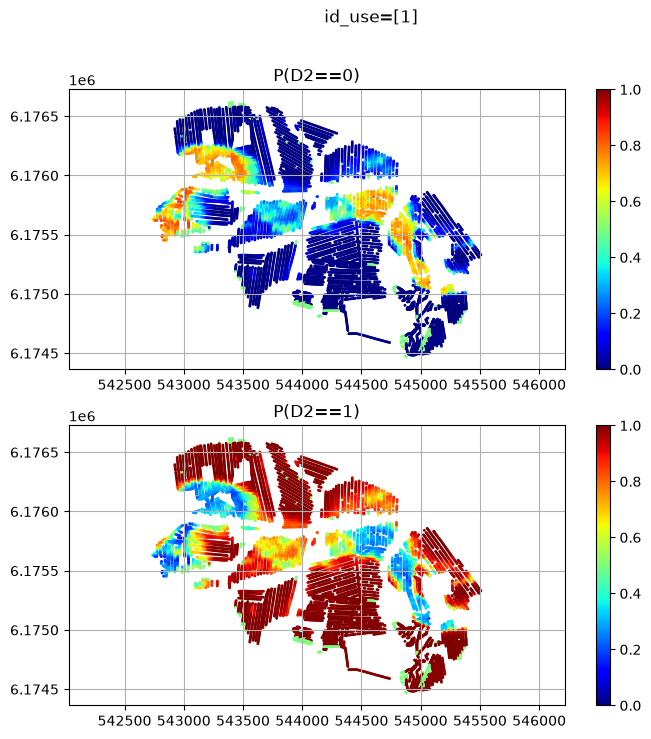

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

...

M2-discrete:  79%|█████████████████████████████████████████████████████████████████████████████████████▍                      | 9247/11693 [00:05<00:01, 1846.41it/s]

M2-discrete:  95%|█████████████████████████████████████████████████████████████████████████████████████████████████████▌     | 11095/11693 [00:06<00:00, 1846.93it/s]

M3-discrete:   0%|                                                                                                                         | 0/11693 [00:00<?, ?it/s]

M3-discrete:  84%|███████████████████████████████████████████████████████████████████████████████████████████▏                | 9873/11693 [00:01<00:00, 9872.52it/s]

Keys in POSTERIOR
<KeysViewHDF5 ['Entropy', 'Mode', 'P']>


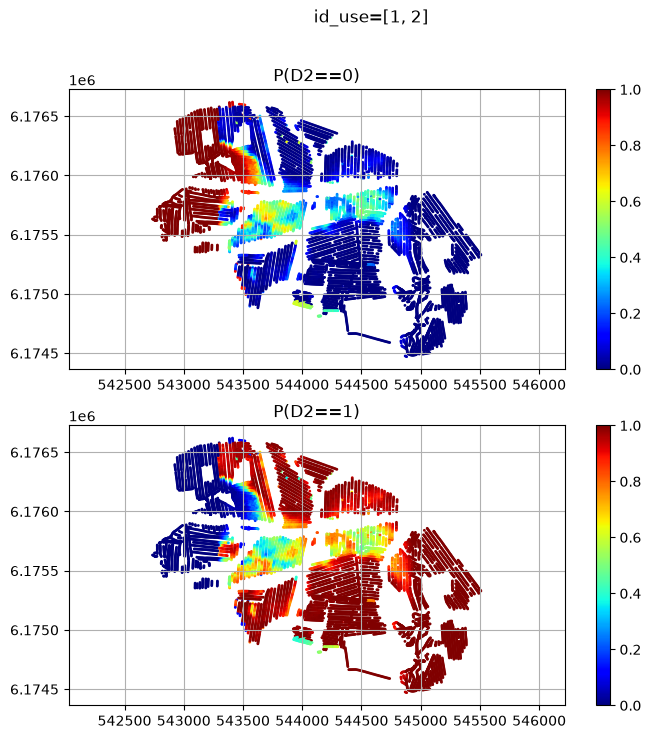

In [7]:
id_use_arr = []
id_use_arr.append([2]) # Dicrete data
id_use_arr.append([1]) # tTEM data
id_use_arr.append([1,2]) # Both discrete and tTEM data

f_post_h5_arr = []
P0_mul = []

for i in range(len(id_use_arr)):

    id_use = id_use_arr[i]
    updatePostStat =True
    f_post_h5 = ig.integrate_rejection(f_prior_h5, f_data_h5, 
                                    parallel=parallel, 
                                    updatePostStat=updatePostStat, 
                                    showInfo=0,
                                    Ncpu=8,
                                    nr=1000,
                                    id_use = id_use)
    f_post_h5_arr.append(f_post_h5)

    #% 
    im=3 # Scenario Category
    with h5py.File(f_post_h5, 'r') as f:
        print("Keys in POSTERIOR")
        print(f['M3'].keys()) 
        post_MODE = f['M3/Mode'][:]
        post_P = f['M3/P'][:]
    
    P = post_P[:,:,0]
    P0_mul.append(P)


    plt.figure(figsize=(8,8))
    for ic in range(nclasses):
        plt.subplot(2,1,ic+1)
        #sc = plt.scatter(X, Y, c=D_obs[:,ic], cmap='jet', vmin=0, vmax=1, s=20)
        sc = plt.scatter(X, Y, c=P[:,ic], cmap='jet', vmin=0, vmax=1, s=1)
        plt.colorbar(sc)
        plt.title('P(D2==%d)'%(ic))
        plt.axis('equal')
        plt.grid()
    plt.suptitle(' id_use=%s' % (id_use))
    plt.show()

    # ig.plot_profile(f_post_h5, im=2, i1=0, i2=1000)

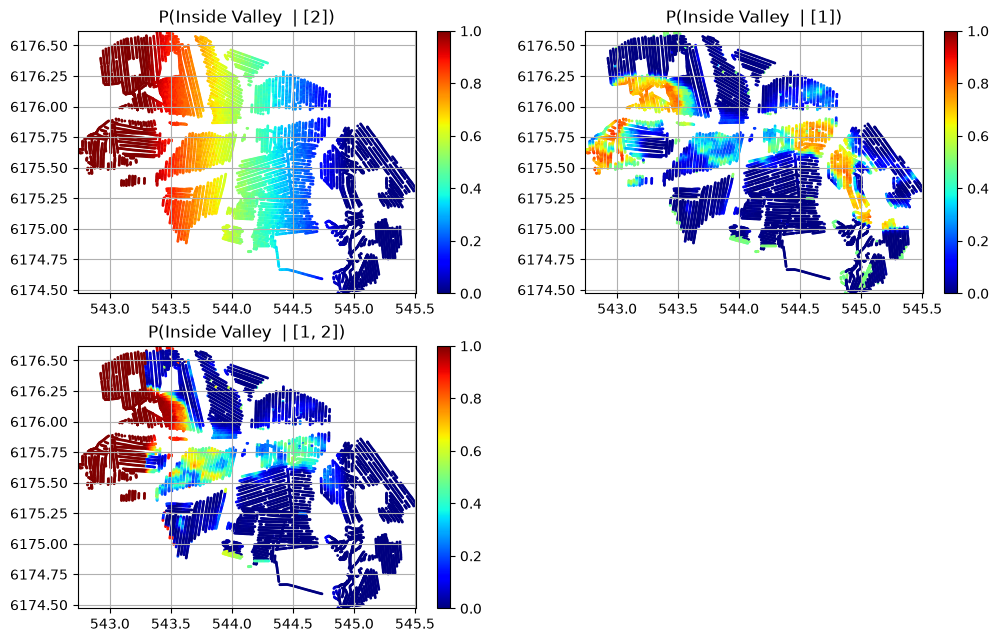

In [8]:
n=len(f_post_h5_arr)
plt.figure(figsize=(12,2.5*n))
for i in range(n):
    plt.subplot(2,2,i+1)
    sc = plt.scatter(X/1000, Y/1000, c=P0_mul[i][:,0], cmap='jet', vmin=0, vmax=1, s=1)
    plt.colorbar(sc)
    plt.grid()
    plt.title('P(D2==%d)'%(ic))
    plt.axis('equal')
    # TIght axes
    plt.xlim([X.min()/1000,X.max()/1000])
    plt.ylim([Y.min()/1000,Y.max()/1000])
    plt.title('P(Inside Valley  | %s)' % (id_use_arr[i]))

    

